In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [11]:
df = pd.read_csv(r"C:\Users\rvams\Downloads\titanic (1).csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
import os

for root, dirs, files in os.walk(".", topdown=True):
    if "diabetes_data.csv" in files:
        print("Found at:", os.path.join(root, "titanic.csv"))


Found at: .\titanic.csv


## STEP 1: EDA

In [12]:
missing = df.isna().sum().to_frame("Missing Count")
missing["Missing %"] = (df.isna().sum() / len(df)) * 100
missing


,Missing Count,Missing %
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


In [13]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()


Duplicate rows: 0


In [14]:
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns

outlier_bounds = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_bounds[col] = (lower, upper)


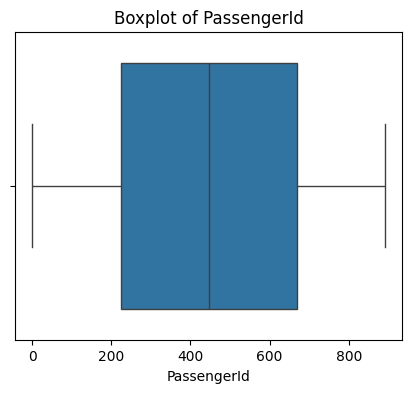

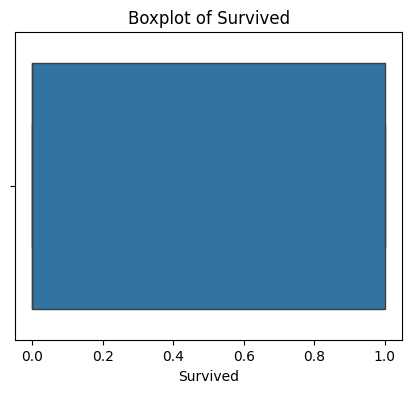

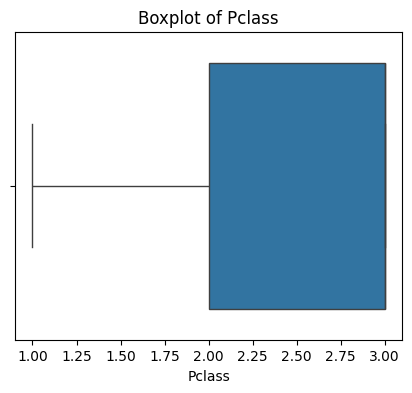

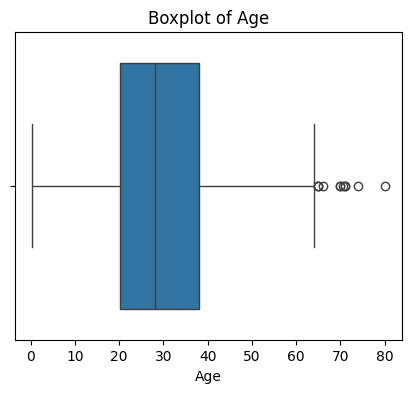

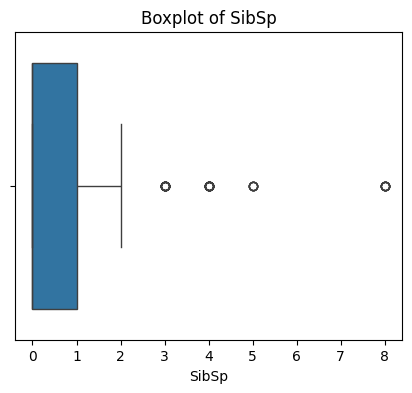

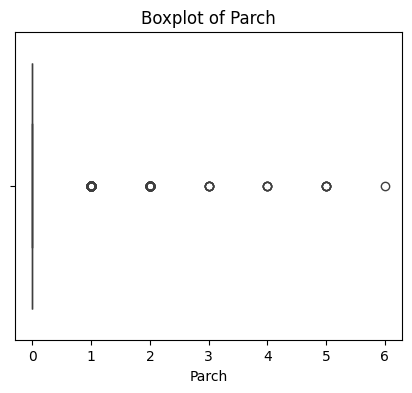

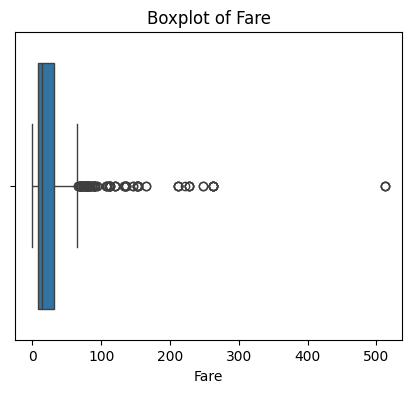

In [15]:
for col in numeric_cols:
    plt.figure(figsize=(5,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


In [16]:
df_capped = df.copy()

for col, (lower, upper) in outlier_bounds.items():
    df_capped[col] = np.where(df_capped[col] < lower, lower, df_capped[col])
    df_capped[col] = np.where(df_capped[col] > upper, upper, df_capped[col])


## STEP 2: SELECT TARGET VARIABLE

In [17]:
y = df_capped["Survived"]


## STEP 3: PREPROCESSING & FEATURE SCALING

In [20]:
# 3.1 FEATURE ENGINEERING

df_fe = df_capped.copy()

# FamilySize
df_fe["FamilySize"] = df_fe["SibSp"] + df_fe["Parch"] + 1

# IsAlone
df_fe["IsAlone"] = (df_fe["FamilySize"] == 1).astype(int)

# Title extraction (FIXED)
df_fe["Title"] = df_fe["Name"].str.extract(r', (.*)\.', expand=False)

# HasCabin
df_fe["HasCabin"] = df_fe["Cabin"].notna().astype(int)


In [21]:
# Age group median
df_fe["Age"] = df_fe["Age"].fillna(df_fe.groupby(["Sex","Pclass"])["Age"].transform("median"))

# Embarked
df_fe["Embarked"] = df_fe["Embarked"].fillna(df_fe["Embarked"].mode()[0])

# Fare
df_fe["Fare"] = df_fe["Fare"].fillna(df_fe["Fare"].median())


In [22]:
df_model = df_fe.drop(columns=["Name", "Ticket", "Cabin", "PassengerId", "Survived"])
X = df_model


In [23]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(include=["int64","float64"]).columns


In [24]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)


## STEP 4: BUILD ML MODELS

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [26]:
logreg_pipeline = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=200))
])

logreg_pipeline.fit(X_train, y_train)
y_pred_lr = logreg_pipeline.predict(X_test)


## STEP 5: EVALUATION

In [28]:
print(" Logistic Regression Accuracy =", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))


 Logistic Regression Accuracy = 0.8212290502793296
              precision    recall  f1-score   support

         0.0       0.82      0.90      0.86       110
         1.0       0.81      0.70      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179

[[99 11]
 [21 48]]


In [32]:
# 4.3 Decision Tree Pipeline (TRAINING)

tree_pipeline = Pipeline([
    ("prep", preprocess),
    ("model", DecisionTreeClassifier(random_state=42))
])

tree_pipeline.fit(X_train, y_train)

# PREDICTION (this defines y_pred_tree)
y_pred_tree = tree_pipeline.predict(X_test)

print("Decision Tree Model Trained Successfully!")


Decision Tree Model Trained Successfully!


In [33]:
print("📌 Decision Tree Accuracy =", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))
print(confusion_matrix(y_test, y_pred_tree))


📌 Decision Tree Accuracy = 0.776536312849162
              precision    recall  f1-score   support

         0.0       0.81      0.84      0.82       110
         1.0       0.72      0.68      0.70        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.76       179
weighted avg       0.77      0.78      0.78       179

[[92 18]
 [22 47]]


In [34]:
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_tree = accuracy_score(y_test, y_pred_tree)

if acc_lr >= acc_tree:
    print("Best Model = Logistic Regression")
else:
    print("Best Model = Decision Tree")


Best Model = Logistic Regression


In [36]:
# ---------- Minimal, Reusable Titanic Pipeline ----------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# --- 1) Load & Inspect ---
df = pd.read_csv(r"C:\Users\rvams\Downloads\titanic (1).csv")  # change path if needed
print("Missing by column:\n", df.isna().sum())
print("Duplicate rows:", df.duplicated().sum())

# --- 2) De-dup ---
df = df.drop_duplicates().copy()

# --- 3) Outliers (IQR capping) ---
def iqr_caps(frame, cols=None):
    frame = frame.copy()
    if cols is None:
        cols = frame.select_dtypes(include=[np.number]).columns
    for c in cols:
        s = frame[c].dropna()
        if s.empty: 
            continue
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        low, up = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        frame[c] = np.where(frame[c] < low, low, frame[c])
        frame[c] = np.where(frame[c] > up, up, frame[c])
    return frame

df = iqr_caps(df)

# --- 4) Engineer & Impute ---
df["FamilySize"] = df["SibSp"].fillna(0) + df["Parch"].fillna(0) + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["HasCabin"] = (~df["Cabin"].isna()).astype(int) if "Cabin" in df.columns else 0
# robust title extraction (raw string to avoid warnings)
df["Title"] = df["Name"].str.extract(r", (.*)\.", expand=False) if "Name" in df.columns else np.nan

# Imputations
if {"Age","Sex","Pclass"}.issubset(df.columns):
    age_gmed = df.groupby(["Sex","Pclass"])["Age"].transform("median")
    df["Age"] = df["Age"].fillna(age_gmed)
if "Age" in df.columns:
    df["Age"] = df["Age"].fillna(df["Age"].median())
if "Embarked" in df.columns:
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
if "Fare" in df.columns:
    df["Fare"] = df["Fare"].fillna(df["Fare"].median())

# Drop unused text/id columns
drop_cols = [c for c in ["Name","Ticket","Cabin","PassengerId"] if c in df.columns]
df_clean = df.drop(columns=drop_cols)

# --- 5) Split ---
y = df_clean["Survived"]
X = df_clean.drop(columns=["Survived"])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 6) Pipeline (scaling + one-hot) ---
cat_cols = X.select_dtypes(include=["object","category"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

# Choose a model: LogisticRegression or DecisionTreeClassifier
logreg = Pipeline([("prep", preprocess), ("clf", LogisticRegression(max_iter=200))])
tree   = Pipeline([("prep", preprocess), ("clf", DecisionTreeClassifier(random_state=42))])

# --- 7) Fit & Evaluate ---
logreg.fit(X_train, y_train)
tree.fit(X_train, y_train)

pred_lr = logreg.predict(X_test)
pred_tr = tree.predict(X_test)

acc_lr = accuracy_score(y_test, pred_lr)
acc_tr = accuracy_score(y_test, pred_tr)

print(f"\nLogReg accuracy:  {acc_lr:.4f}")
print(classification_report(y_test, pred_lr))
print("Confusion Matrix (LogReg):\n", confusion_matrix(y_test, pred_lr))

print(f"\nTree accuracy:    {acc_tr:.4f}")
print(classification_report(y_test, pred_tr))
print("Confusion Matrix (Tree):\n", confusion_matrix(y_test, pred_tr))

best = ("logreg", logreg, acc_lr) if acc_lr >= acc_tr else ("tree", tree, acc_tr)
print(f"\nSelected best model: {best[0]} (accuracy={best[2]:.4f})")

# --- 8) Save artifacts ---
df_clean.to_csv("titanic_cleaned.csv", index=False)
joblib.dump(best[1], f"titanic_{best[0]}_pipeline.pkl")
print("\nSaved: titanic_cleaned.csv and", f"titanic_{best[0]}_pipeline.pkl")


Missing by column:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Duplicate rows: 0

LogReg accuracy:  0.8324
              precision    recall  f1-score   support

         0.0       0.85      0.88      0.87       110
         1.0       0.80      0.75      0.78        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179

Confusion Matrix (LogReg):
 [[97 13]
 [17 52]]

Tree accuracy:    0.7709
              precision    recall  f1-score   support

         0.0       0.81      0.83      0.82       110
         1.0       0.71      0.68      0.70        69

    accuracy                           0.77       179
   macro avg       0.76      0.75      0.76       179
weighted avg       0.77